In [1]:
from navigation_training_data_extractor import NavigationTrainingDataExtractor
from ae_robot_simulation_control import RobotNavigationControl

spp = NavigationTrainingDataExtractor("train_55")
rnc = RobotNavigationControl()
rnc.set_controller(spp.get_controller())
doors = spp.find_all_doors()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[AI2-THOR WARNING] There has been an update to ProcTHOR-10K that must be used with AI2-THOR version 5.0+. To use the new version of ProcTHOR-10K, please update AI2-THOR to version 5.0+ by running:
    pip install --upgrade ai2thor
Alternatively, to downgrade to the old version of ProcTHOR-10K, run:
   prior.load_dataset("procthor-10k", revision="ab3cacd0fc17754d4c080a3fd50b18395fae8647")


Loading test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8860.33it/s]


Loading : train[55]
ROOMS:[('Kitchen', [(0.0, 1.82), (0.0, 7.28), (7.28, 7.28), (7.28, 1.82)]), ('LivingRoom', [(0.0, 7.28), (0.0, 10.92), (5.46, 10.92), (9.1, 10.92), (9.1, 9.1), (7.28, 9.1), (7.28, 7.28)]), ('LivingRoom', [(0.0, 10.92), (0.0, 14.56), (5.46, 14.56), (5.46, 10.92)]), ('Bathroom', [(5.46, 10.92), (5.46, 14.56), (9.1, 14.56), (9.1, 10.92)]), ('Bedroom', [(7.28, 1.82), (7.28, 7.28), (14.56, 7.28), (14.56, 3.64), (10.92, 3.64), (10.92, 1.82)]), ('Bedroom', [(14.56, 0.0), (10.92, 0.0), (10.92, 1.82), (10.92, 3.64), (14.56, 3.64)]), ('Bedroom', [(7.28, 9.1), (9.1, 9.1), (9.1, 10.92), (14.56, 10.92), (14.56, 7.28), (7.28, 7.28)])]


{'name': 'door|4|5', 'position': {'x': 5.459979057312012, 'y': -0.0005959272384643555, 'z': 12.668745040893555}, 'rotation': {'x': -0.0, 'y': 90.0, 'z': -0.0}, 'visible': False, 'isInteractable': False, 'receptacle': False, 'toggleable': False, 'isToggled': False, 'breakable': False, 'isBroken': False, 'canFillWithLiquid': False, 'isFilledWithLiquid': False, 'fillLiquid': None, 'dirtyable': False, 'isDirty': False, 'canBeUsedUp': False, 'isUsedUp': False, 'cookable': False, 'isCooked': False, 'temperature': 'RoomTemp', 'isHeatSource': False, 'isColdSource': False, 'sliceable': False, 'isSliced': False, 'openable': True, 'isOpen': True, 'openness': 1.0, 'pickupable': False, 'isPickedUp': False, 'moveable': False, 'mass': 0.0, 'salientMaterials': None, 'receptacleObjectIds': None, 'distance': 3.458458185195923, 'objectType': 'Doorway', 'objectId': 'door|4|5', 'assetId': 'Doorway_9', 'parentReceptacles': ['Floor'], 'controlledObjects': None, 'isMoving': False, 'axisAlignedBoundingBox': {'

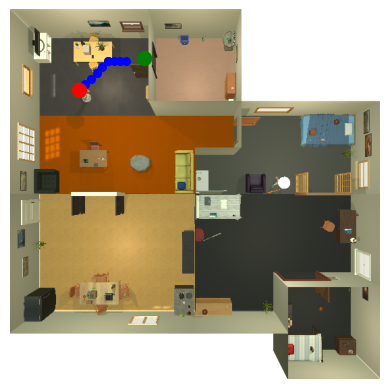

In [8]:
door_of_interest = doors[3]
print(door_of_interest)
path_and_plan = spp.get_path_to_actual_object(door_of_interest, is_door=True)
path = path_and_plan[0]
plan = path_and_plan[1]
spp.visualise_path(path)


In [9]:
door_of_interest = doors[3]
path_and_plan = spp.get_path_to_actual_object(door_of_interest, is_door=True)
path = path_and_plan[0]
plan = path_and_plan[1]

for element in path:
    print(element)
#print(path

rnc.follow_planned_path(path)

# AE: target_position:  (5.037323951721191, 1.0371887683868408, 13.133256912231445)
# AE: obj_pos:  {'x': 5.459979057312012, 'y': -0.0005959272384643555, 'z': 12.668745040893555}
# AE: start_pose:  ((2.25, 0.9009997844696045, 11.75), (-0.0, 270.0, 0.0))
AE: v_angles: [0] # h_angles: [0, 45, 90, 135, 180, 225, 270, 315] # movement_params: {'RotateLeft': {'degrees': 45}, 'RotateRight': {'degrees': 45}, 'MoveAhead': {'moveMagnitude': 0.25}, 'LookUp': {'degrees': 30}, 'LookDown': {'degrees': 30}} # goal_distance: 1.0 # diagonal_ok: True # positions_only: False # return_plan: True # as_tuples: False
AE: tp:  (5.037323951721191, 1.0371887683868408, 13.133256912231445)  # tps:  (5.459979057312012, -0.0005959272384643555, 12.668745040893555)
AE: goal:  ((5.037323951721191, 1.0371887683868408, 13.133256912231445), (-0.0, 270.0, 0.0))
AE: goal_rotation after normalize:  (0.0, 270.0, 0.0)
AE: nav_actions:  [('RotateLeft', (0.0, -45, 0.0)), ('RotateRight', (0.0, 45, 0.0)), ('MoveAhead', (0.25, 0.0

In [11]:
doors_sorted = spp.get_all_doors_sorted_by_distance_from_current_pose()
#for (door in doors_sorted):
#    path = door[1]
#    rnc.navigate_to_pose()

path = doors_sorted[1][1]
#for pose in path:
#    print(rnc.get_agent_pos_and_rotation())
#    rnc.navigate_to_pose(pose)
rnc.follow_planned_path(path)

# AE: target_position:  (-8.195638656616211e-08, 1.0496989488601685, 6.499107360839844)
# AE: obj_pos:  {'x': 5.0032027502311394e-05, 'y': -0.0005983114242553711, 'z': 5.9759392738342285}
# AE: start_pose:  ((2.25, 0.9009997844696045, 11.75), (-0.0, 270.0, 0.0))
v_angles: [0] # h_angles: [0, 45, 90, 135, 180, 225, 270, 315] # movement_params: {'MoveAhead': {'moveMagnitude': 0.25}, 'LookUp': {'degrees': 30}, 'LookDown': {'degrees': 30}, 'RotateLeft': {'degrees': 45}, 'RotateRight': {'degrees': 45}} # goal_distance: 1.0 # diagonal_ok: False # positions_only: False # return_plan: True # as_tuples: False
AE: tp:  (-8.195638656616211e-08, 1.0496989488601685, 6.499107360839844)  # tps:  (5.0032027502311394e-05, -0.0005983114242553711, 5.9759392738342285)
AE: goal:  ((-8.195638656616211e-08, 1.0496989488601685, 6.499107360839844), (-0.0, 270.0, 0.0))
AE: goal_rotation after normalize:  (0.0, 270.0, 0.0)
AE last_position: (0.75, 0.9009997844696045, 6.0) # target_position: (-8.195638656616211e-

In [4]:
print(path)

[({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.75}, {'x': 0.0, 'y': 225.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.75}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.5}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.25}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.0}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.75}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.5}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.25}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.0}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.0}, {'x': 0.0, 'y': 135.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 2.5, 'y': 0.9009997844696045, 'z': 10.0}, {'x': 0.0, 

0.0 14.5 0.0 14.5


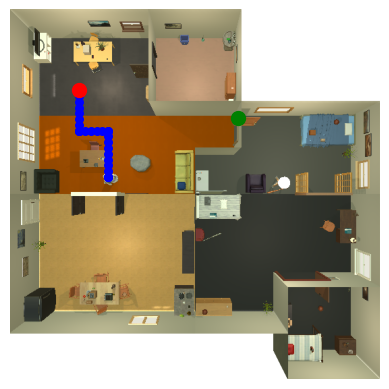

In [3]:
#path = spp.get_path_to_actual_object(doors_sorted[0])
spp.visualise_path(path)

In [4]:
#for i in range(10):
rnc.return_to_prev_pose()

((2.25, 0.9009997844696045, 11.75), (-0.0, 270.0, 0.0))
navigating to:  ((2.25, 0.9009997844696045, 11.75), (-0.0, 270.0, 0.0))


In [6]:
rnc.controller.step(action="Done")

<ai2thor.server.Event at 0x7f4ed6cc25f0
    .metadata["lastAction"] = Done
    .metadata["lastActionSuccess"] = True
    .metadata["errorMessage"] = "
    .metadata["actionReturn"] = None
>

In [6]:
print(path)

[({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.75}, {'x': 0.0, 'y': 225.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.75}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.5}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.25}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.0}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.75}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.5}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.25}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.0}, {'x': 0.0, 'y': 180.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.0}, {'x': 0.0, 'y': 135.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 10.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 2.5, 'y': 0.9009997844696045, 'z': 10.0}, {'x': 0.0, 

In [17]:
path = doors_sorted[0][1]
#for pose in path:
#    print(rnc.get_agent_pos_and_rotation())
#    rnc.navigate_to_pose(pose)
rnc.follow_planned_path(path)

navigating to:  ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.75}, {'x': 0.0, 'y': 315.0, 'z': 0.0})
navigating to:  ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.75}, {'x': 0.0, 'y': 0.0, 'z': 0.0})
navigating to:  ({'x': 2.25, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 0.0, 'z': 0.0})
navigating to:  ({'x': 2.25, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 45.0, 'z': 0.0})
navigating to:  ({'x': 2.25, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0})
navigating to:  ({'x': 2.5, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0})
navigating to:  ({'x': 2.75, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0})
navigating to:  ({'x': 3.0, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0})
navigating to:  ({'x': 3.25, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0})
navigating to:  ({'x': 3.5, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0})
navigating t

In [18]:
print(doors_sorted[0])

(4.0, [({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.75}, {'x': 0.0, 'y': 315.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 11.75}, {'x': 0.0, 'y': 0.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 0.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 45.0, 'z': 0.0}), ({'x': 2.25, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 2.5, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 2.75, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 3.0, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 3.25, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 3.5, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 3.75, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 'z': 0.0}), ({'x': 4.0, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 0.0, 'y': 90.0, 

In [26]:
print(doors[3])

{'name': 'door|4|5', 'position': {'x': 5.459979057312012, 'y': -0.0005959272384643555, 'z': 12.668745040893555}, 'rotation': {'x': -0.0, 'y': 90.0, 'z': -0.0}, 'visible': False, 'isInteractable': False, 'receptacle': False, 'toggleable': False, 'isToggled': False, 'breakable': False, 'isBroken': False, 'canFillWithLiquid': False, 'isFilledWithLiquid': False, 'fillLiquid': None, 'dirtyable': False, 'isDirty': False, 'canBeUsedUp': False, 'isUsedUp': False, 'cookable': False, 'isCooked': False, 'temperature': 'RoomTemp', 'isHeatSource': False, 'isColdSource': False, 'sliceable': False, 'isSliced': False, 'openable': True, 'isOpen': True, 'openness': 1.0, 'pickupable': False, 'isPickedUp': False, 'moveable': False, 'mass': 0.0, 'salientMaterials': None, 'receptacleObjectIds': None, 'distance': 3.458458185195923, 'objectType': 'Doorway', 'objectId': 'door|4|5', 'assetId': 'Doorway_9', 'parentReceptacles': ['Floor'], 'controlledObjects': None, 'isMoving': False, 'axisAlignedBoundingBox': {'

In [27]:
rnc.navigate_to_pose(({'x': 4.75, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 60.0, 'y': 45.0, 'z': 0.0}))

navigating to:  ({'x': 4.75, 'y': 0.9009997844696045, 'z': 12.0}, {'x': 60.0, 'y': 45.0, 'z': 0.0})
